In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
df = pd.read_csv("/content/final_internship_data.csv")

In [2]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  i

In [3]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
    User ID          User Name       Driver Name Car Condition Weather  \
0  KHVrEVlD     Kimberly Adams        Amy Butler     Very Good   windy   
1  lPxIuEri       Justin Tapia  Hannah Zimmerman     Excellent  cloudy   
2  gsVN8JLS    Elizabeth Lopez    Amanda Jackson           Bad  stormy   
3  9I7kWFgd      Steven Wilson          Amy Horn     Very Good  stormy   
4  8QN5ZaGN  Alexander Andrews  Cassandra Larson           Bad  stormy   

   Traffic Condition                            key  fare_amount  \
0  Congested Traffic    2009-06-15 17:26:21.0000001          4.5   
1       Flow Traffic    2010-01-05 16:52:16.0000002         16.9   
2  Congested Traffic   2011-08-18 00:35:00.00000049          5.7   
3       Flow Traffic    2012-04-21 04:30:42.0000001          7.7   
4  Congested Traffic  2010-03-09 07:51:00.000000135          5.3   

       pickup_datetime  pickup_longitude  ...  month  weekday  year  \
0  2009-06-15 17:26:21         -1.288826  ...      6        

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [5]:
df.isnull().sum()

,0
User ID,0
User Name,0
Driver Name,0
Car Condition,0
Weather,0
Traffic Condition,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0


In [6]:
df.duplicated().sum()

0

In [7]:
print("\nSummary Statistics:")
print(df.describe(include='all'))


Summary Statistics:
         User ID      User Name    Driver Name Car Condition Weather  \
count     500000         500000         500000        500000  500000   
unique    500000         221675         221700             4       5   
top     KHVrEVlD  Michael Smith  Michael Smith     Very Good   sunny   
freq           1            224            257        125312  100433   
mean         NaN            NaN            NaN           NaN     NaN   
std          NaN            NaN            NaN           NaN     NaN   
min          NaN            NaN            NaN           NaN     NaN   
25%          NaN            NaN            NaN           NaN     NaN   
50%          NaN            NaN            NaN           NaN     NaN   
75%          NaN            NaN            NaN           NaN     NaN   
max          NaN            NaN            NaN           NaN     NaN   

        Traffic Condition                          key    fare_amount  \
count              500000                

In [8]:
categorical_cols = ['User Name', 'Driver Name', 'Car Condition', 'Weather', 'Traffic Condition']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

<ipython-input-8-abd6ebbdb20a>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [9]:
numeric_cols = ['fare_amount', 'distance', 'bearing', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

<ipython-input-9-603f9c64478f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


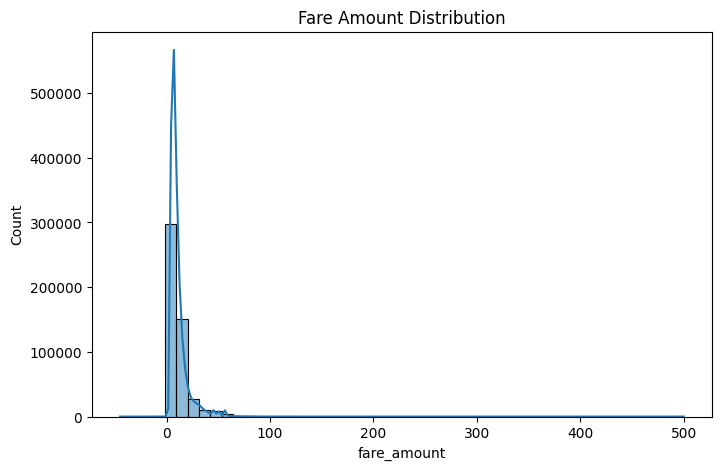

In [10]:
# Univariate Analysis - Distribution of fares
plt.figure(figsize=(8, 5))
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title("Fare Amount Distribution")
plt.show()

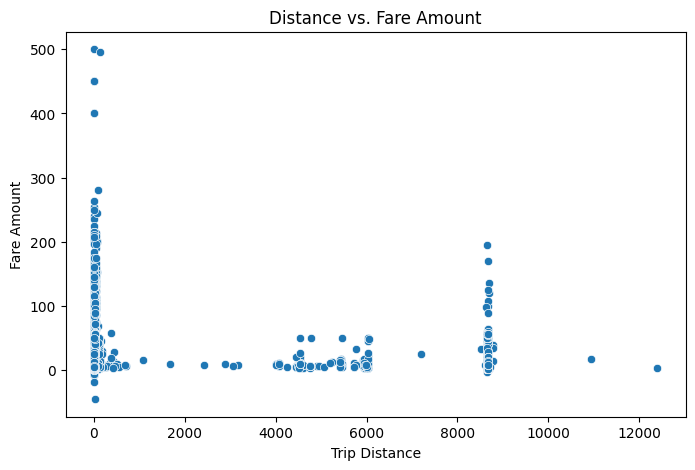

In [11]:
# Relationship between distance and fare
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['distance'], y=df['fare_amount'])
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Distance vs. Fare Amount")
plt.show()

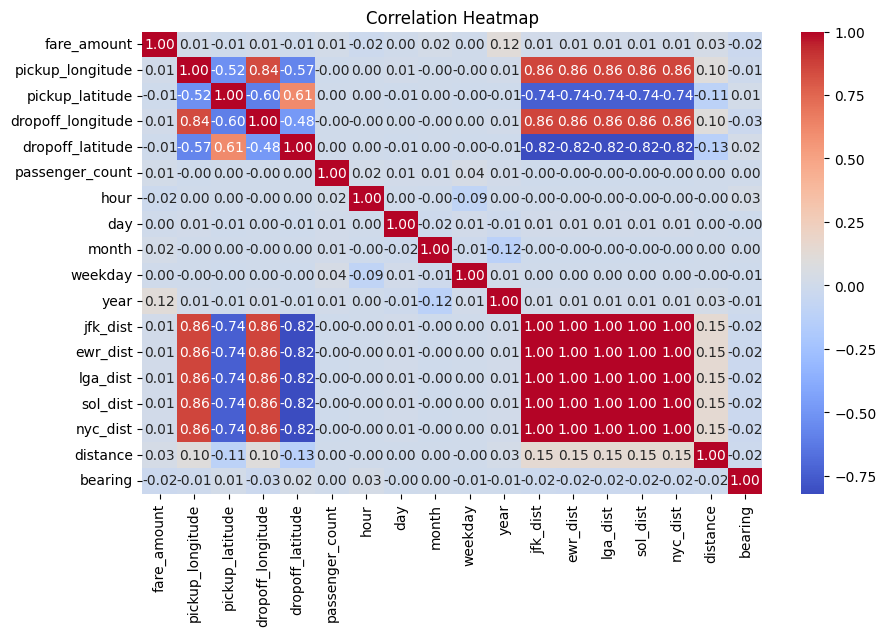

In [13]:
# Heatmap for correlation analysis
plt.figure(figsize=(10, 6))
# Calculate correlation only for numeric columns
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

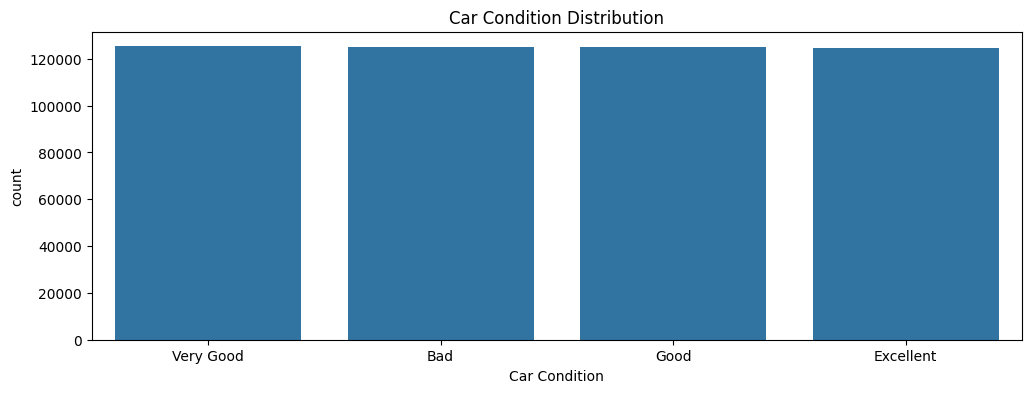

In [14]:
plt.figure(figsize=(12, 4))
sns.countplot(x=df['Car Condition'], order=df['Car Condition'].value_counts().index)
plt.title("Car Condition Distribution")
plt.show()

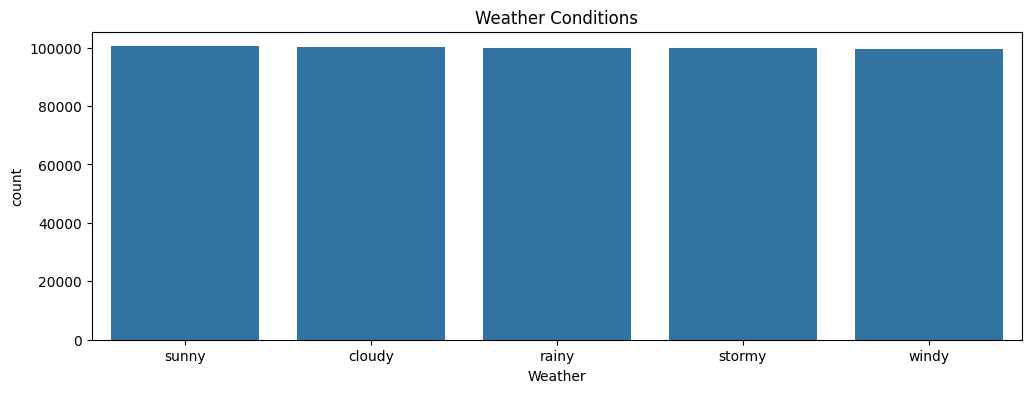

In [15]:
plt.figure(figsize=(12, 4))
sns.countplot(x=df['Weather'], order=df['Weather'].value_counts().index)
plt.title("Weather Conditions")
plt.show()

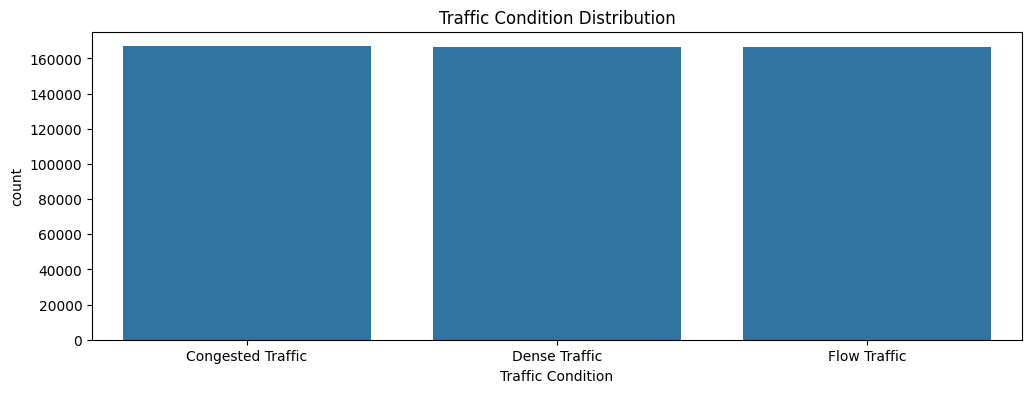

In [16]:
plt.figure(figsize=(12, 4))
sns.countplot(x=df['Traffic Condition'], order=df['Traffic Condition'].value_counts().index)
plt.title("Traffic Condition Distribution")
plt.show()